# 03 - Revenue EDA

## 1. Purpose
Explore the shape of the revenue trend: growth phase vs. plateau, volatility,
and distribution -- as a precursor to the growth-metric calculations in
`04_growth_analysis.ipynb`.


## 2. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


## 3. Data Loading

In [1]:
df = pd.read_csv("../data/raw/monthly_revenue_raw.csv")
df['sales_month'] = pd.to_datetime(df['sales_month'], format='%Y-%m')
df = df.sort_values('sales_month').reset_index(drop=True)
df.rename(columns={'current_month_revenue': 'revenue'}, inplace=True)
df.head()


  sales_month  revenue
0  2016-10-01    43000
1  2016-11-01   105000
2  2016-12-01   253000
3  2017-01-01   390000
4  2017-02-01   362000

## 4. Analysis

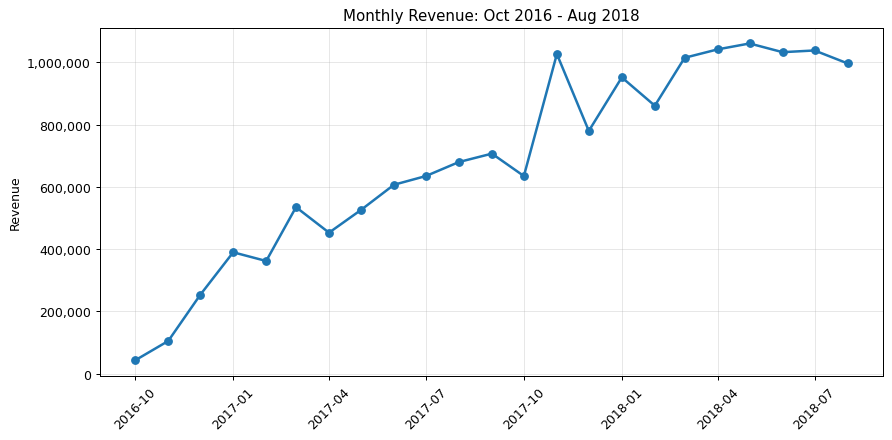

In [1]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['sales_month'], df['revenue'], marker='o', linewidth=2)
ax.set_title('Monthly Revenue: Oct 2016 - Aug 2018')
ax.set_ylabel('Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [1]:
print(df['revenue'].describe())
print()
print("First 3 months (ramp period):")
print(df.head(3)[['sales_month', 'revenue']])
print()
print("Last 12 months mean:", round(df['revenue'].tail(12).mean(), 2))
print("First 12 months mean:", round(df['revenue'].head(12).mean(), 2))


count          23.00
mean      684,239.17
std       315,444.74
min        43,000.00
25%       489,500.00
50%       680,000.00
75%     1,005,987.00
max     1,061,000.00
Name: revenue, dtype: float64

First 3 months (ramp period):
  sales_month  revenue
0  2016-10-01    43000
1  2016-11-01   105000
2  2016-12-01   253000

Last 12 months mean: 929041.75
First 12 months mean: 441333.33


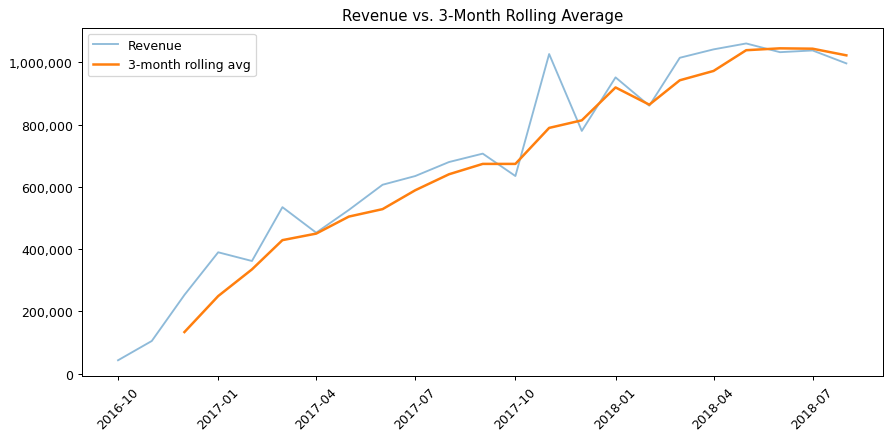

In [1]:
# Rolling volatility
df['rolling_3m_avg'] = df['revenue'].rolling(3).mean()
df['rolling_3m_std'] = df['revenue'].rolling(3).std()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['sales_month'], df['revenue'], label='Revenue', alpha=0.5)
ax.plot(df['sales_month'], df['rolling_3m_avg'], label='3-month rolling avg', linewidth=2)
ax.legend()
ax.set_title('Revenue vs. 3-Month Rolling Average')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Findings

- Revenue rises from **43,000 (Oct-2016)** to a first plateau around
  **~680,000-707,000 (mid-to-late 2017)**, then jumps to a period peak of
  **1,027,013 (Nov-2017)**, before settling into a **~860,000-1,061,000
  band** from Jan-2018 through Aug-2018.
- The shape is consistent with a launch ramp followed by a maturing,
  range-bound phase -- not sustained exponential growth. The rate of
  increase visibly slows after the Nov-2017 peak.
- The 3-month rolling average confirms the plateau: from Jan-2018 onward,
  the rolling average moves in a narrow band rather than trending steeply
  in either direction.
- Because there is no order-count or customer data, this notebook **cannot**
  say whether the plateau reflects demand saturation, seasonality, capacity
  constraints, or something else -- only that the revenue trend itself has
  flattened. See `docs/assumptions.md` for the boundary between what this
  data can and cannot explain.


## 6. Conclusion

Revenue shows a clear two-phase pattern: a 2016-2017 ramp and a 2018
plateau. Proceed to `04_growth_analysis.ipynb` to quantify this precisely
with MoM/YoY growth, running totals, and streak detection.
